In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image, ImageOps
from pathlib import Path
import matplotlib.pyplot as plt

random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [5]:
DATA_DIR = Path.home()/"Downloads"/"new_CatsandDogs"

IMG_SIZE = 224
BATCH_SIZE = 32
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.25, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
    transforms.RandomErasing(p=0.3),    
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

train_base = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_base = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

class_names = eval_base.classes
labels = eval_base.targets

idx_train, idx_rest = train_test_split(
    list(range(len(labels))), test_size=0.30, random_state=42, stratify=labels)
idx_val, idx_test = train_test_split(
    idx_rest, test_size=0.50, random_state=42, stratify=[labels[i] for i in idx_rest])

train_ds = Subset(train_base, idx_train)
val_ds = Subset(eval_base, idx_val)
test_ds = Subset(eval_base, idx_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"{len(class_names)} classes: {class_names}")
print(f"{len(labels)} images total -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

print(f"\n{'breed':<28}{'train':>7}{'val':>6}{'test':>6}")
for c, name in enumerate(class_names):
    row = [sum(1 for i in idx if labels[i] == c) for idx in (idx_train, idx_val, idx_test)]
    print(f"{name:<28}{row[0]:>7}{row[1]:>6}{row[2]:>6}")

37 classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
7315 images total -> train 5120 | val 1097 | test 1098

breed                         train   val  test
Abyssinian                      136    29    29
Bengal                          140    30    30
Birman                          139    30    30
Bombay                          123    27    26
British_Shorthair               139    29    30
Egyptian_Mau                    135    29    28
Maine_Coon     

In [6]:
NUM_CLASSES = len(class_names)
MIX_PROB = 0.5  

mixup = v2.MixUp(alpha=0.2, num_classes=NUM_CLASSES)
cutmix = v2.CutMix(alpha=1.0, num_classes=NUM_CLASSES)


def paste_grid(images, labels, row_edges, col_edges):
    B, _, H, W = images.shape
    onehot = F.one_hot(labels, NUM_CLASSES).float()
    out = torch.empty_like(images)
    soft_labels = torch.zeros_like(onehot)
    for top, bottom in zip(row_edges[:-1], row_edges[1:]):
        for left, right in zip(col_edges[:-1], col_edges[1:]):
            pick = torch.randperm(B, device=images.device)
            out[:, :, top:bottom, left:right] = F.interpolate(images[pick], size=(bottom - top, right - left), mode="bilinear")
            soft_labels += onehot[pick] * (bottom - top) * (right - left) / (H * W)
    return out, soft_labels


def mosaic(images, labels):
    H, W = images.shape[2:]
    y_cut = int(H * random.uniform(0.3, 0.7))
    x_cut = int(W * random.uniform(0.3, 0.7))
    return paste_grid(images, labels, [0, y_cut, H], [0, x_cut, W])


def dynamic_mosaic(images, labels):
    H, W = images.shape[2:]
    rows, cols = random.choice([(2, 2), (2, 3), (3, 2), (3, 3)])
    return paste_grid(images, labels, [H * r // rows for r in range(rows + 1)], [W * c // cols for c in range(cols + 1)])


def mix_batch(images, labels):
    if random.random() < MIX_PROB:
        augment = random.choice([mixup, cutmix, mosaic, dynamic_mosaic])
        return augment(images, labels)
    return images, F.one_hot(labels, NUM_CLASSES).float()

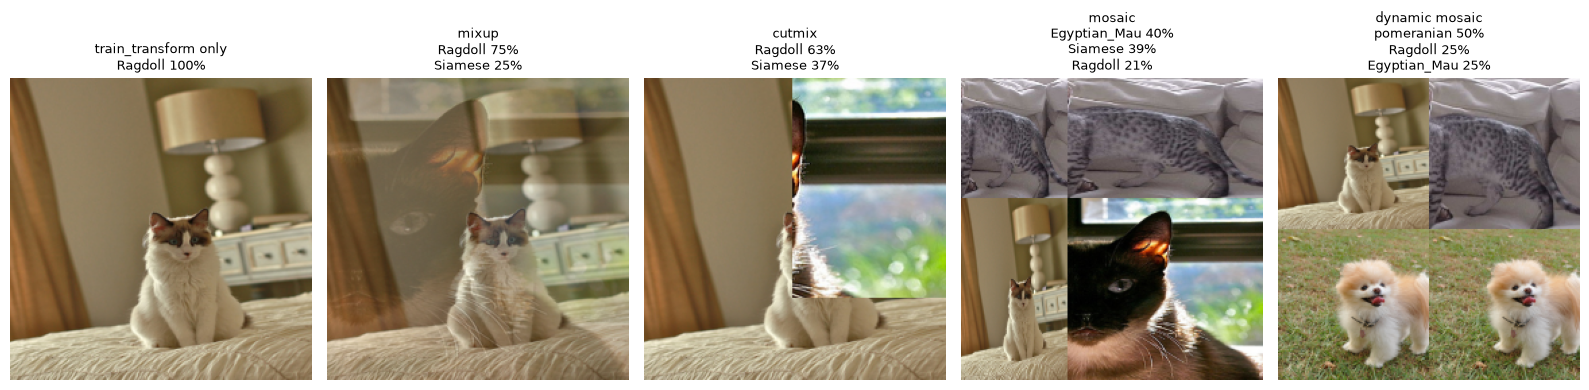

In [ ]:
x = torch.stack([train_ds[i][0] for i in range(8)])   
y = torch.tensor([train_ds[i][1] for i in range(8)])
mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
std = torch.tensor(NORM_STD).view(3, 1, 1)

examples = [("train_transform only", x, F.one_hot(y, NUM_CLASSES).float())]
for name, augment in [("mixup", mixup), ("cutmix", cutmix), ("mosaic", mosaic), ("dynamic mosaic", dynamic_mosaic)]:
    images, soft_labels = augment(x, y)
    examples.append((name, images, soft_labels))

fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))
for ax, (name, images, soft_labels) in zip(axes, examples):
    shares, classes = soft_labels[0].topk(3)
    label_text = "\n".join(f"{class_names[c]} {s:.0%}" for s, c in zip(shares, classes) if s >= 0.005)
    ax.imshow((images[0] * std + mean).permute(1, 2, 0).clamp(0, 1))   
    ax.set_title(f"{name}\n{label_text}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

print(f"resnet18 from scratch -> {len(class_names)} classes")

resnet18 from scratch -> 37 classes


In [9]:
EPOCHS = 100
WARMUP_EPOCHS = 5
CKPT_PATH = "Oxford_pets_scratch.pth"

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)

warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])


@torch.no_grad()
def accuracy(loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


history = []
best_acc, best_epoch, best_state = -1.0, 0, None

for epoch in range(1, EPOCHS + 1):
    lr = optimizer.param_groups[0]["lr"]
    model.train()
    running_loss = correct = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        x, soft_y = mix_batch(x, y)    
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, soft_y)    
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == soft_y.argmax(1)).sum().item()    
    scheduler.step()

    train_loss = running_loss / len(train_ds)
    train_acc = correct / len(train_ds)
    val_acc = accuracy(val_loader)
    history.append((train_loss, train_acc, val_acc))

    mark = ""
    if val_acc > best_acc:
        best_acc, best_epoch = val_acc, epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        mark = "  <- best so far"
    print(f"epoch {epoch:>2}/{EPOCHS}  lr {lr:.1e}  train loss {train_loss:.3f}  train acc {train_acc:.3f}  val acc {val_acc:.3f}{mark}")

model.load_state_dict(best_state)

torch.save({
    "model_state": best_state,
    "class_names": class_names,
    "arch": "resnet18",
    "img_size": IMG_SIZE,
    "norm_mean": NORM_MEAN,
    "norm_std": NORM_STD,
    "val_accuracy": best_acc,
    "epoch": best_epoch,
}, CKPT_PATH)

print(f"\nSaved epoch {best_epoch} (val accuracy {best_acc:.3f}) to {CKPT_PATH}")

epoch  1/100  lr 1.0e-04  train loss 3.504  train acc 0.066  val acc 0.087  <- best so far
epoch  2/100  lr 2.8e-04  train loss 3.468  train acc 0.078  val acc 0.096  <- best so far
epoch  3/100  lr 4.6e-04  train loss 3.375  train acc 0.101  val acc 0.103  <- best so far
epoch  4/100  lr 6.4e-04  train loss 3.340  train acc 0.112  val acc 0.134  <- best so far
epoch  5/100  lr 8.2e-04  train loss 3.299  train acc 0.116  val acc 0.139  <- best so far
epoch  6/100  lr 1.0e-03  train loss 3.245  train acc 0.132  val acc 0.071
epoch  7/100  lr 1.0e-03  train loss 3.177  train acc 0.148  val acc 0.139
epoch  8/100  lr 1.0e-03  train loss 3.146  train acc 0.160  val acc 0.124
epoch  9/100  lr 1.0e-03  train loss 3.067  train acc 0.174  val acc 0.188  <- best so far
epoch 10/100  lr 1.0e-03  train loss 2.990  train acc 0.195  val acc 0.226  <- best so far
epoch 11/100  lr 9.9e-04  train loss 2.944  train acc 0.209  val acc 0.184
epoch 12/100  lr 9.9e-04  train loss 2.881  train acc 0.229  va

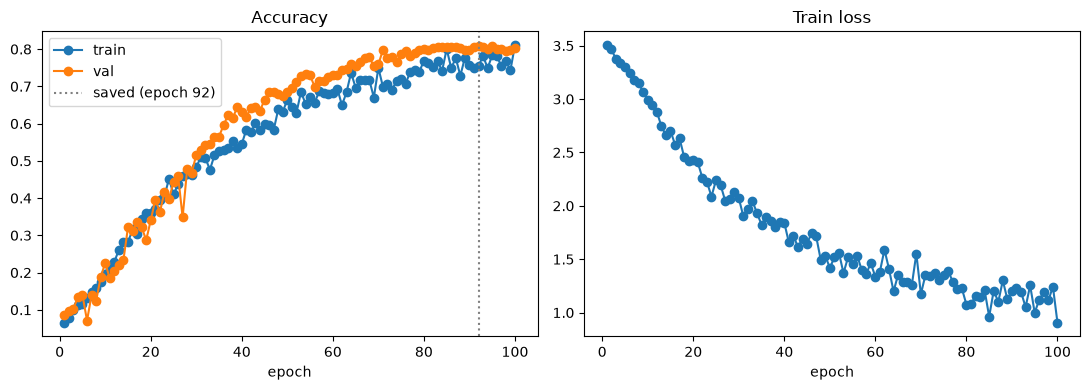

In [10]:
train_loss_h, train_acc_h, val_acc_h = zip(*history)
epochs = range(1, len(history) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(epochs, train_acc_h, marker="o", label="train")
ax1.plot(epochs, val_acc_h, marker="o", label="val")
ax1.axvline(best_epoch, color="gray", linestyle=":", label=f"saved (epoch {best_epoch})")
ax1.set(title="Accuracy", xlabel="epoch")
ax1.legend()
ax2.plot(epochs, train_loss_h, marker="o")
ax2.set(title="Train loss", xlabel="epoch")
plt.tight_layout()
plt.show()

val  accuracy = 0.809  (used to pick the epoch)
test accuracy = 0.812  (the number to report)
206 wrong out of 1098 images

                            precision    recall  f1-score   support

                Abyssinian      0.806     0.862     0.833        29
                    Bengal      0.808     0.700     0.750        30
                    Birman      0.812     0.867     0.839        30
                    Bombay      0.963     1.000     0.981        26
         British_Shorthair      0.839     0.867     0.852        30
              Egyptian_Mau      0.875     1.000     0.933        28
                Maine_Coon      0.812     0.867     0.839        30
                   Persian      0.857     0.800     0.828        30
                   Ragdoll      0.710     0.733     0.721        30
              Russian_Blue      0.929     0.867     0.897        30
                   Siamese      0.800     0.800     0.800        30
                    Sphynx      0.818     0.900     0.857  

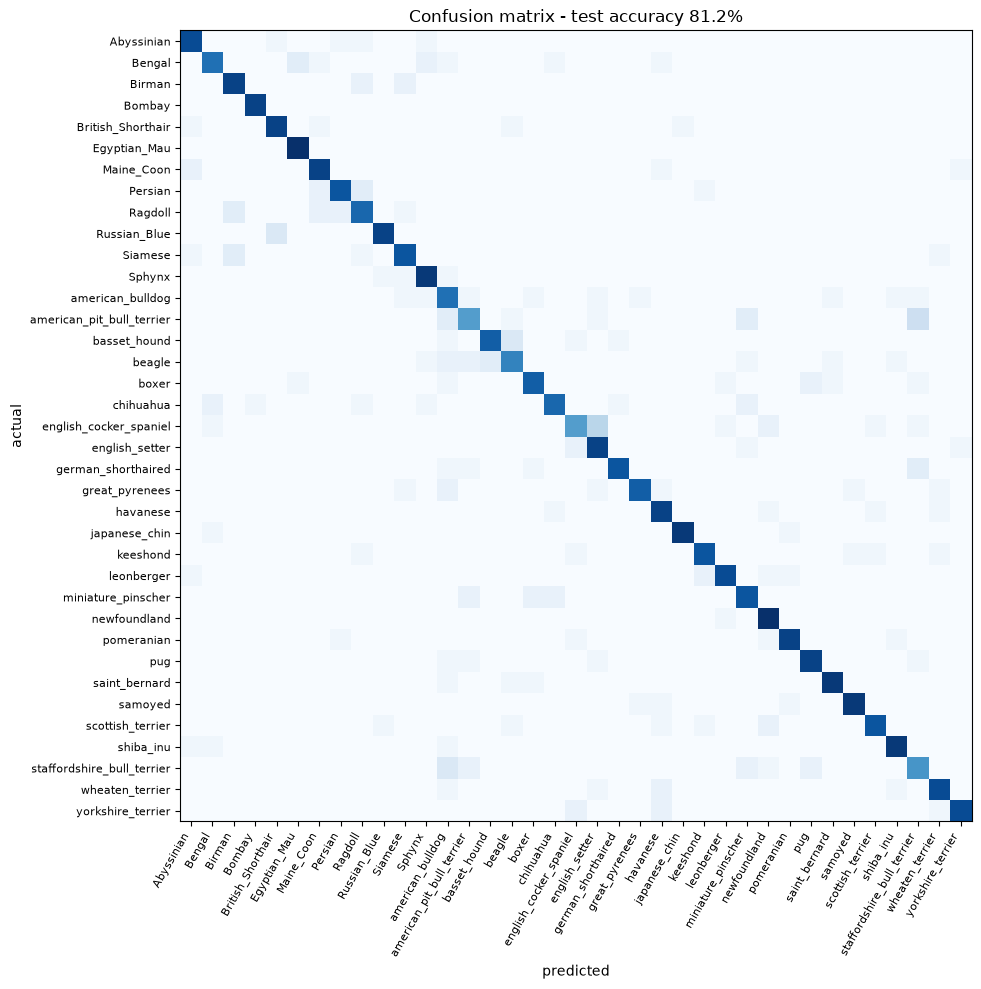

Most confused pairs (actual -> predicted):
  english_cocker_spaniel -> english_setter  8 images
  american_pit_bull_terrier -> staffordshire_bull_terrier  6 images
  staffordshire_bull_terrier -> american_bulldog  4 images
  basset_hound -> beagle  4 images
  Russian_Blue -> British_Shorthair  4 images
  german_shorthaired -> staffordshire_bull_terrier  3 images
  beagle -> basset_hound  3 images
  american_pit_bull_terrier -> miniature_pinscher  3 images
  american_pit_bull_terrier -> american_bulldog  3 images
  Siamese -> Birman  3 images


In [11]:
@torch.no_grad()
def collect(loader):
    model.eval()
    ys, preds = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


y_true, y_pred = collect(test_loader)
test_acc = (y_true == y_pred).mean()

print(f"val  accuracy = {best_acc:.3f}  (used to pick the epoch)")
print(f"test accuracy = {test_acc:.3f}  (the number to report)")
print(f"{int((y_true != y_pred).sum())} wrong out of {len(y_true)} images\n")

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)), class_names, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(class_names)), class_names, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title(f"Confusion matrix - test accuracy {test_acc:.1%}")
plt.tight_layout()
plt.show()

mistakes = [(cm[i, j], class_names[i], class_names[j])
            for i in range(len(class_names)) for j in range(len(class_names)) if i != j and cm[i, j]]
print("Most confused pairs (actual -> predicted):")
for n, a, b in sorted(mistakes, reverse=True)[:10]:
    print(f"  {a} -> {b}  {n} images")

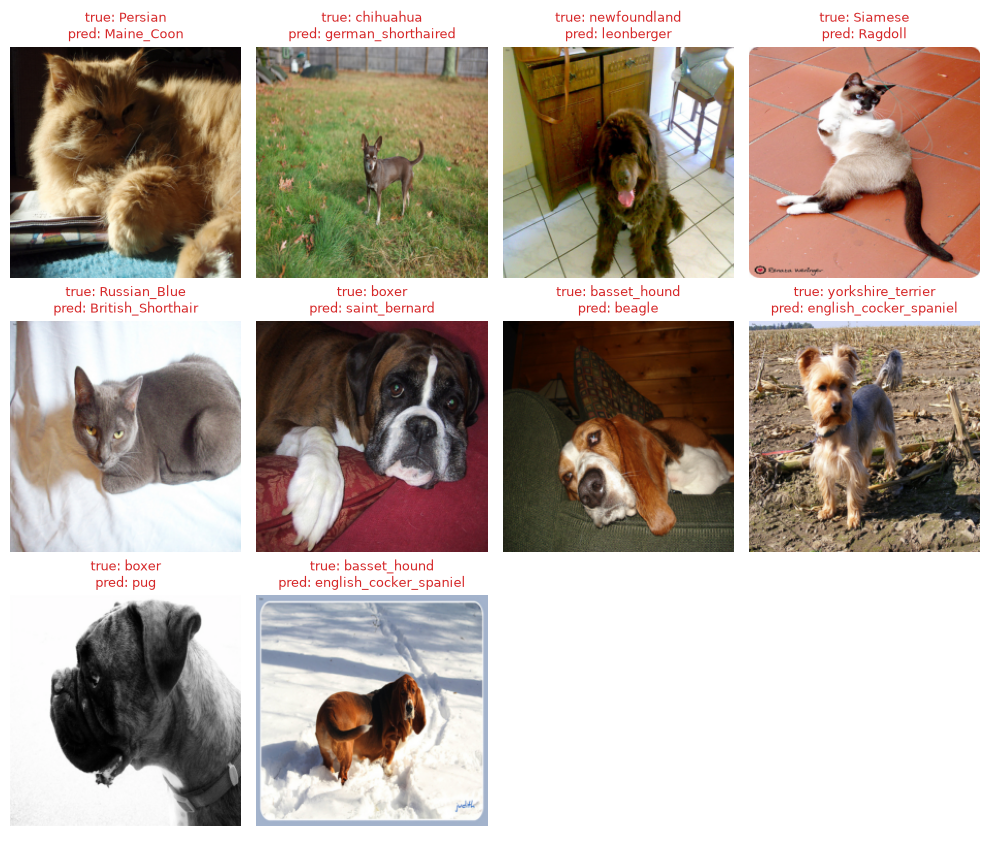

In [12]:
MAX_SHOW = 10
mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
std = torch.tensor(NORM_STD).view(3, 1, 1)

wrong = []
for i, (t, p) in enumerate(zip(y_true, y_pred)):
    if t != p and len(wrong) < MAX_SHOW:
        img, _ = test_ds[i]
        wrong.append((img * std + mean, class_names[t], class_names[p]))   # undo Normalize so the colors look right

fig, axes = plt.subplots(3, 4, figsize=(10, 8.5))
for ax in axes.flat:
    ax.axis("off")
for ax, (img, t, p) in zip(axes.flat, wrong):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f"true: {t}\npred: {p}", fontsize=9, color="tab:red")
plt.tight_layout()
plt.show()

In [ ]:
CKPT_PATH = "Oxford_pets_scratch_augment.pth"

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=True)
names = ckpt["class_names"]

net = models.resnet18()
net.fc = nn.Linear(net.fc.in_features, len(names))
net.load_state_dict(ckpt["model_state"])
net = net.to(device).eval()

tf = transforms.Compose([
    transforms.Resize((ckpt["img_size"], ckpt["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(ckpt["norm_mean"], ckpt["norm_std"]),
])

print(f"Loaded {CKPT_PATH}: epoch {ckpt['epoch']}, val accuracy {ckpt['val_accuracy']:.3f}, {len(names)} classes")

Loaded Oxford_pets_scratch.pth: epoch 92, val accuracy 0.809, 37 classes


In [14]:
def open_image(path):
    return ImageOps.exif_transpose(Image.open(path)).convert("RGB")   # exif_transpose turns phone photos the right way up


@torch.no_grad()
def predict(path, topk=3):
    x = tf(open_image(path)).unsqueeze(0).to(device)
    probs = torch.softmax(net(x), dim=1)[0]
    p, i = probs.topk(topk)
    return [(names[c], v.item()) for v, c in zip(p, i)]


def show(path, topk=3):
    top = predict(path, topk)
    plt.figure(figsize=(4, 4))
    plt.imshow(open_image(path))
    plt.axis("off")
    plt.title(f"{top[0][0]}  ({top[0][1]:.1%})")
    plt.show()
    for name, conf in top:
        print(f"  {name:<28} {conf:6.1%}")


NEW_DIR = Path.home()/"Downloads"/"new_pets"
NEW_DIR.mkdir(parents=True, exist_ok=True)
new_images = [p for p in sorted(NEW_DIR.iterdir()) if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]

if not new_images:
    print(f"No images in {NEW_DIR} yet - put some there and run this cell again")
for path in new_images[:10]:    
    print(path.name)
    show(path)

No images in C:\Users\Lenovo\Downloads\new_pets yet - put some there and run this cell again
